In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tips_df = pd.read_csv('C:/Develop/深圳42/data/tips.csv')

In [2]:
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


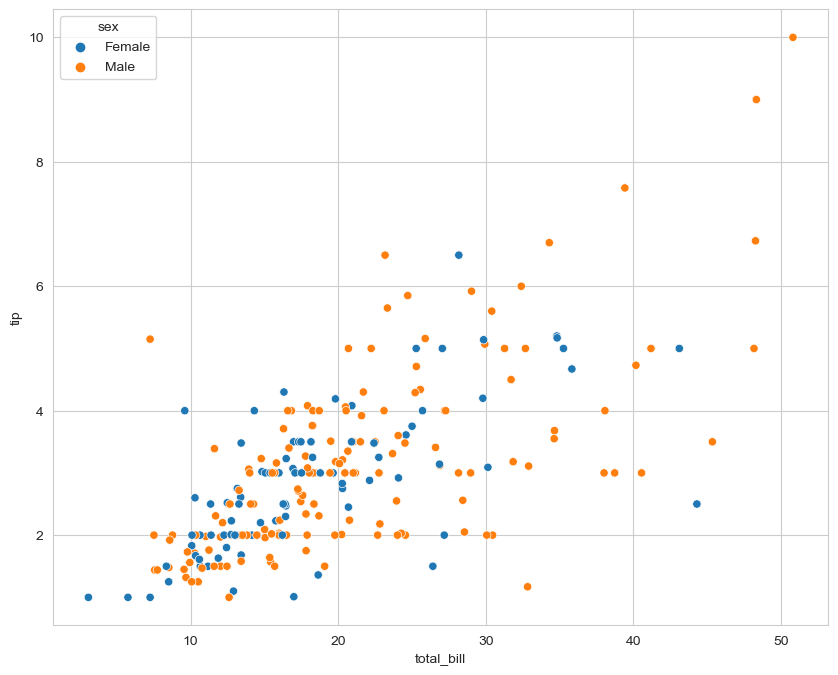

In [10]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='total_bill', y='tip', data=tips_df,hue='sex')
plt.show()
# sns.XXXplot
# data = 传入dataframe 就是要用来画图的数据对应的df对象
#  x, y  df中的列名  用数据中的哪一列作为x值, y值
# hue 传入一个类别型的变量, seaborn 会通过颜色来区分不同类别的数据, 画在同一个图中

<Axes: xlabel='total_bill', ylabel='tip'>

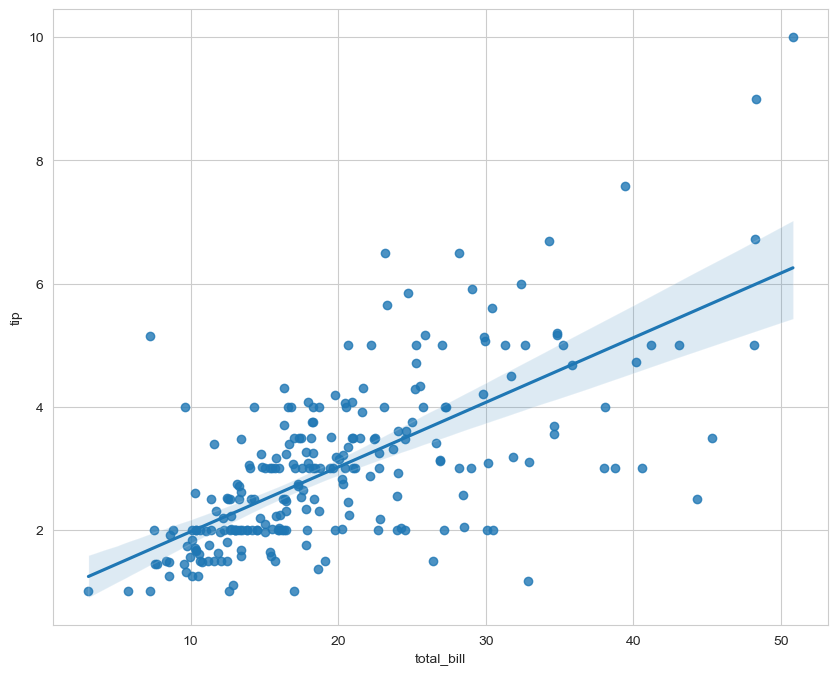

In [19]:
plt.figure(figsize=(10,8))
sns.regplot(data=tips_df, x='total_bill', y='tip',fit_reg=True)

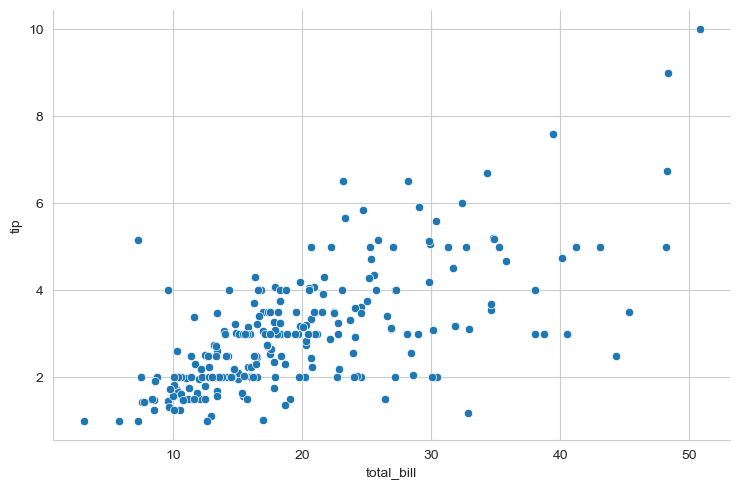

In [23]:
sns.relplot(data=tips_df, x='total_bill', y='tip',kind='scatter',height=5,aspect=1.5)
# height 高度
# aspect 宽度和高度的比例

<Axes: xlabel='time', ylabel='total_bill'>

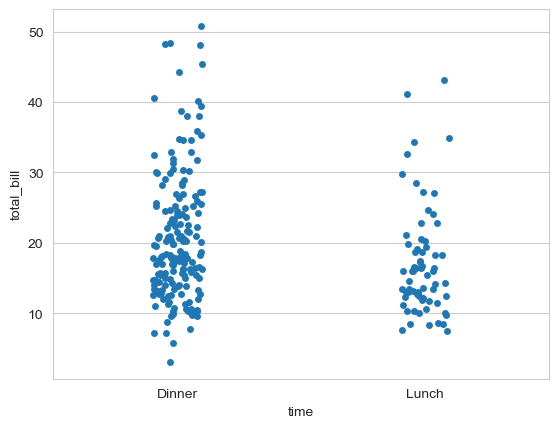

In [24]:
sns.stripplot(data=tips_df,x='time',y='total_bill')

<Axes: xlabel='total_bill', ylabel='Count'>

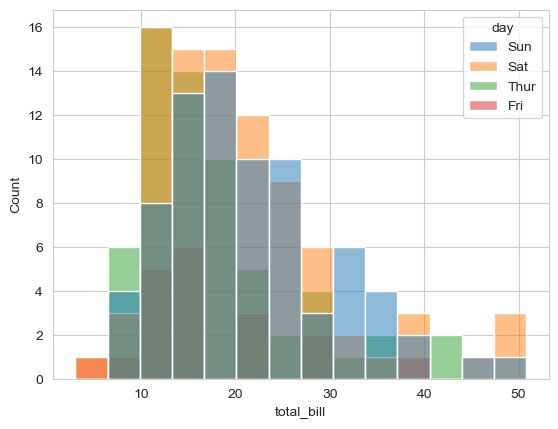

In [28]:
sns.histplot(data=tips_df,x='total_bill',hue='day')

<Axes: xlabel='total_bill', ylabel='Density'>

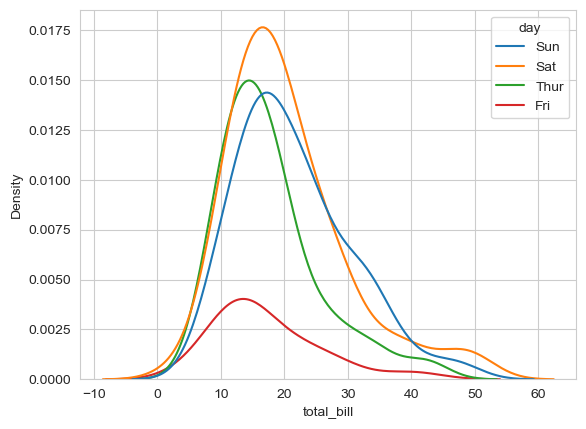

In [29]:
sns.kdeplot(data=tips_df,x='total_bill',hue='day')

<Axes: xlabel='time', ylabel='total_bill'>

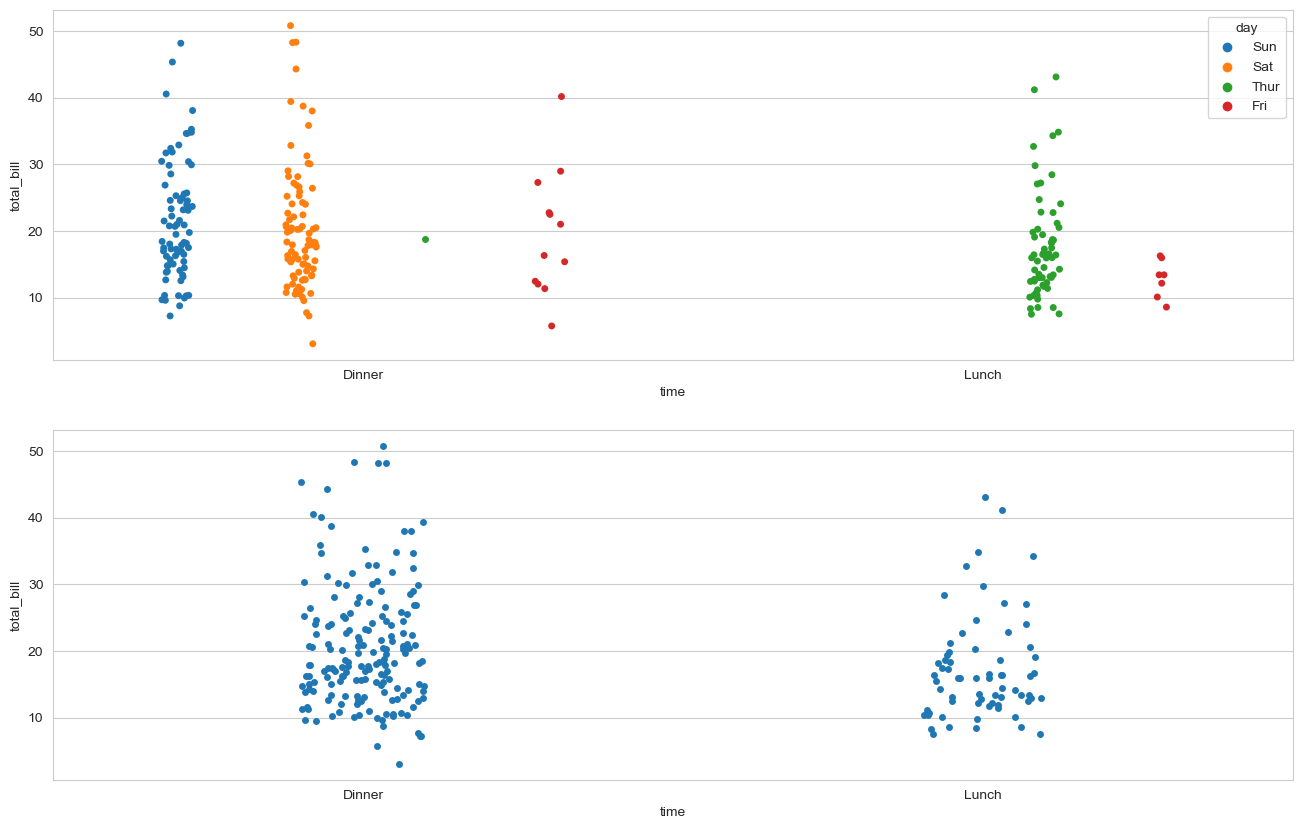

In [35]:
f = plt.figure(figsize=(16,10))
# add_subplot 添加子图
f.add_subplot(211) # 画布区域划分成两行一列在第一个位置画图, 2(两行)1(1列)1第一个位置
sns.stripplot(data=tips_df,x='time',y='total_bill',hue='day',dodge=True,jitter=True)
f.add_subplot(212) # 画布区域划分成两行一列在第二个位置画图, 2(两行)1(1列)2第二个位置
sns.stripplot(data=tips_df,x='time',y='total_bill')

In [ ]:
## 提琴图

<Axes: xlabel='time', ylabel='total_bill'>

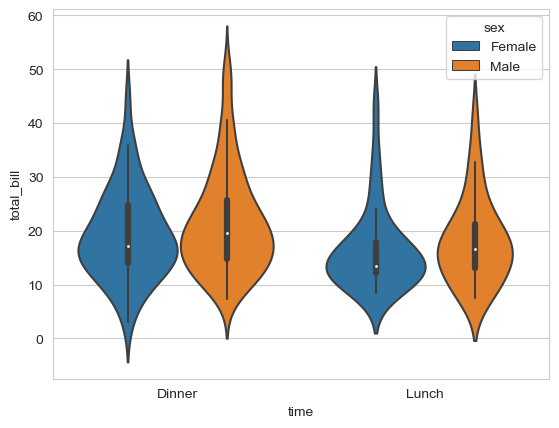

In [40]:
sns.violinplot(data=tips_df,y='total_bill',x='time',hue='sex')

<Axes: xlabel='time', ylabel='total_bill'>

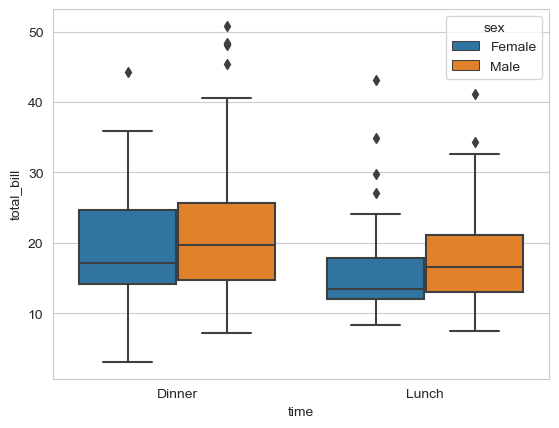

In [41]:
sns.boxplot(data=tips_df,y='total_bill',x='time',hue='sex')

<Axes: xlabel='day', ylabel='total_bill'>

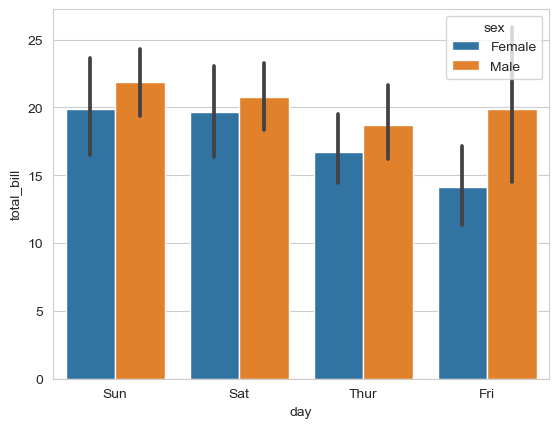

In [58]:
sns.barplot(data=tips_df,x='day',y='total_bill',estimator='mean',hue='sex')
# 对x 进行分组, 对y 进行聚合, 聚合的方法通过estimator来指定, 默认是mean 求平均
# errorbar 误差棒 当数据是抽样的数据, 这个errorbar显示了当前的统计量的置信区间 (可信区间)  因为抽样本身就会带来误差, errorbar的长短跟数据样本数量多少有关, 数据越多errorbar越短, 数据越少errorbar越长
# 如果这里使用的是全部的数据, 不是采样的, 可以设置 errorbar = None 关闭这个误差棒的显示
# estimator  通过这个参数来控制 聚合函数使用哪一个

In [49]:
tips_df['day'].value_counts()

Sat     87
Sun     76
Thur    62
Fri     19
Name: day, dtype: int64

<Axes: xlabel='day'>

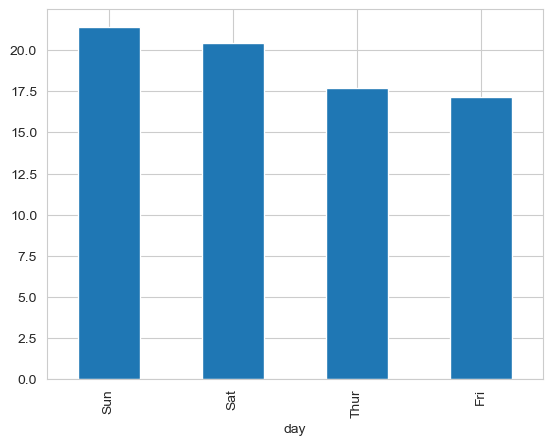

In [46]:
tips_df.groupby('day')['total_bill'].mean().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='day', ylabel='count'>

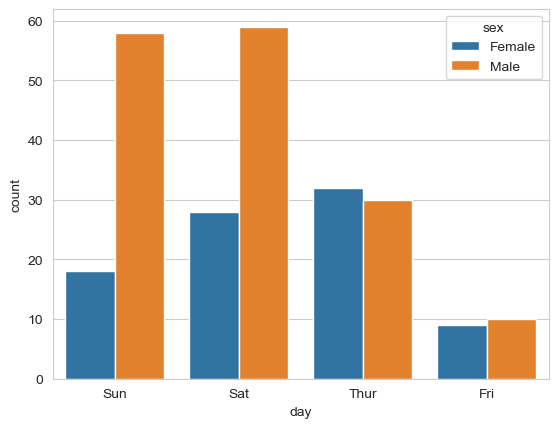

In [61]:
## countplot 计数柱状图
sns.countplot(data=tips_df,x='day',hue='sex')
# tips_df['day'].value_counts().plot.bar()

<Axes: >

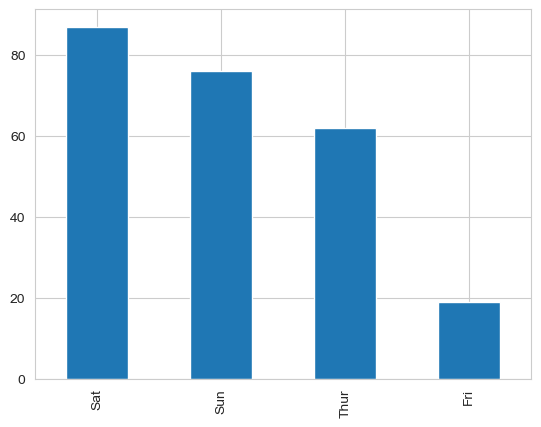

In [60]:
tips_df['day'].value_counts().plot.bar()

<Axes: >

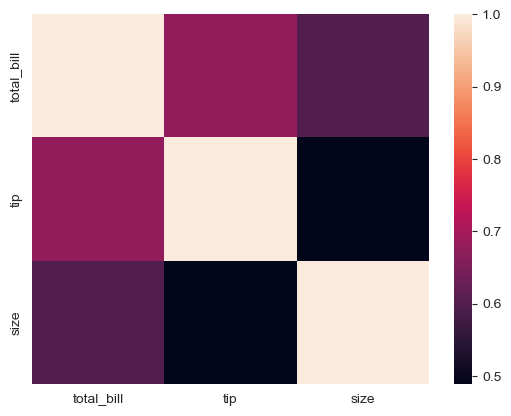

In [63]:
# 热力图  配合 相关系数, 相关系数的可视化一般使用热力图
sns.heatmap(tips_df.corr(numeric_only=True))

In [64]:
tips_df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


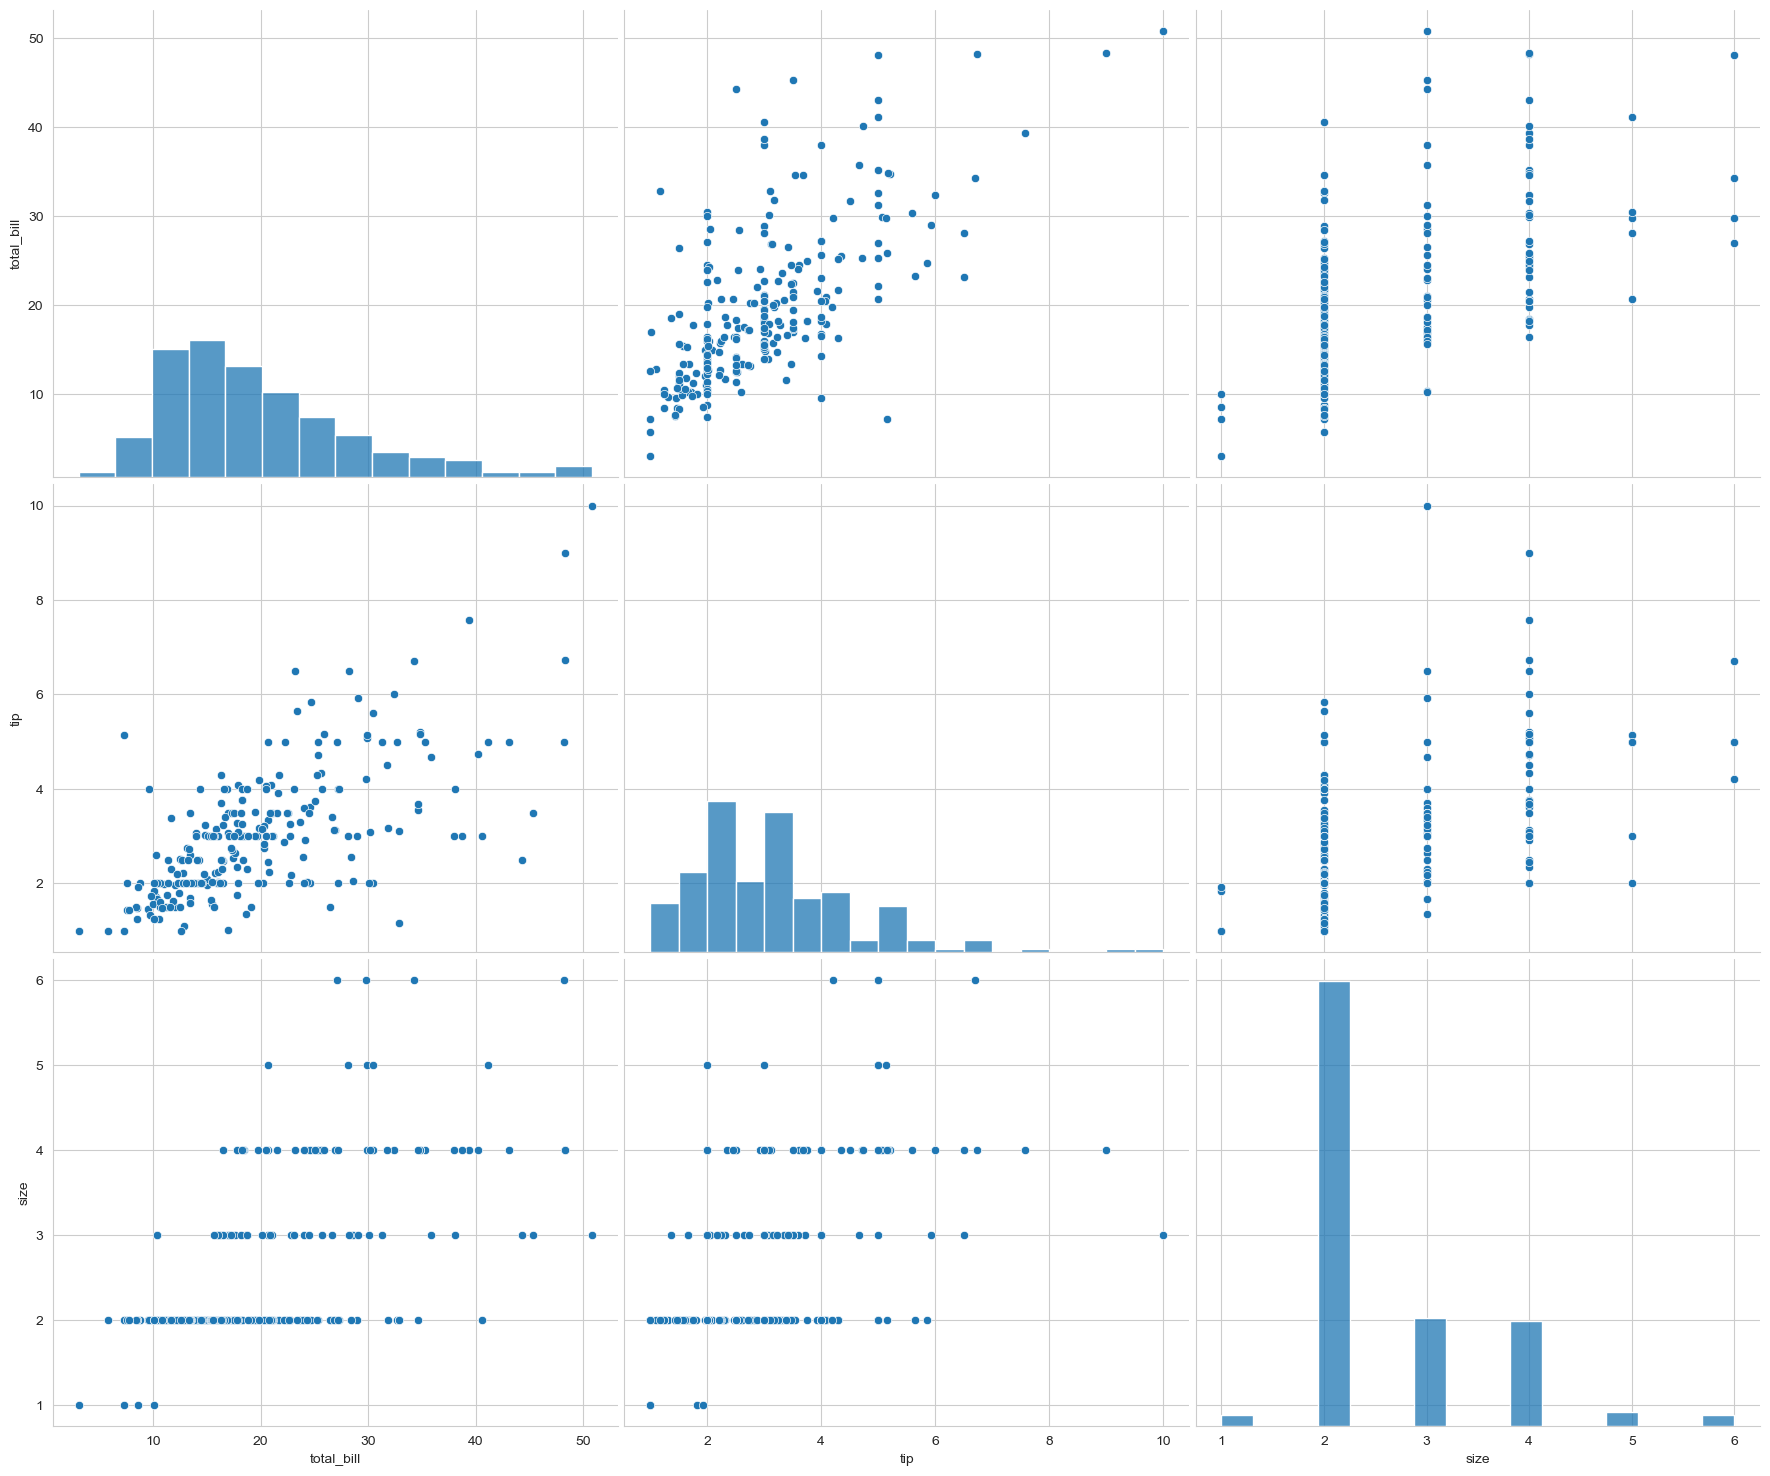

In [68]:
sns.pairplot(tips_df,height=5,aspect=1.2)

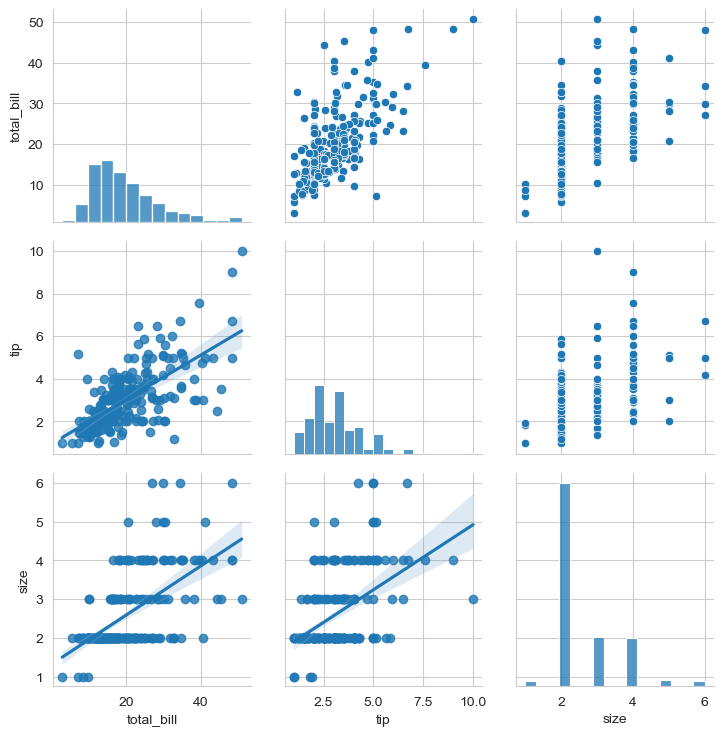

In [73]:
# 成对关系图, 自定义哪一部分使用什么方式进行绘图, 只会绘制数值型的
pair_grid = sns.PairGrid(tips_df) # 确定绘图区域的数量
pair_grid.map_upper(sns.scatterplot) # 右上角 使用的绘图方法对象
pair_grid.map_lower(sns.regplot)# 左下角使用的绘图方法对象
pair_grid.map_diag(sns.histplot) # 对角线 使用的绘图方法对象

<Axes: xlabel='total_bill', ylabel='tip'>

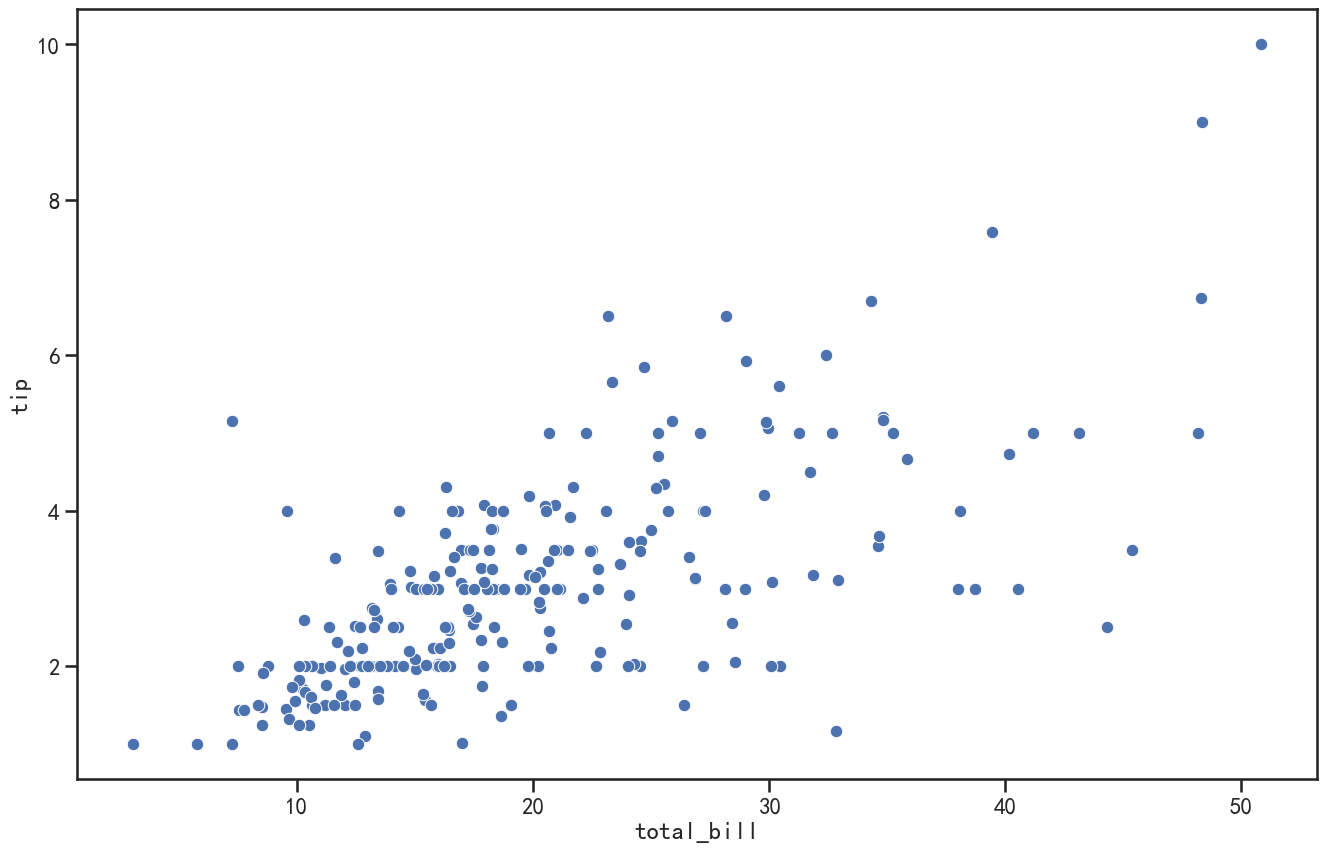

In [95]:
# paper, notebook, talk, poster
# style  white, dark, whitegrid, darkgrid, ticks
fig = plt.figure(figsize=(16,10))
#  {deep, muted,bright, pastel, dark, colorblind}
sns.set(context='talk', style='ticks', palette='deep', font='SimHei', font_scale=1)
sns.scatterplot(data=tips_df,x='total_bill',y='tip')